
En esta versión, generalizamos el caso para N robots, consiguiendo que varios converjan a la trayectoria. También implementamos el control sobre los parámetros $\omega$ para que mantengan las distancias. Todo esto en $R^2$ ($n \equiv dimensión$), por lo que $n = 2$. En otro código trataremos el caso en $R^3$

Implementamos las bibliotecas pertinentes

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
from scipy.integrate import solve_ivp

Definimos los parámetros de la simulación, siendo $n = 2$ las dimensiones (no tocar, falta generalizarlo), $nrob$ el número de robots, $t\_ sim$ el tiempo integrado, y $posmin$ y $posmax$ delimitan los límites en los que se disponen los robots de forma aleatoria.

In [2]:
n = 2
nrob = 10
t_sim = (0,40)
posmin = -6
posmax = 6


A continuación definimos las funciones del algoritmo. $f(t)$ es la curva parametrizada a la que tienden los robots y $df(t)$ es la tangente a la curva. $phi(x,y,t)$ es la distancia de la posición del robot al punto de la curva $f(t)$.

In [3]:
def f(t):
    # fx = t*np.cos(t*2.4)/2
    # fy = t*np.sin(t)/1.5
    fx = np.cos(t)
    fy = np.sin(t)
    
    return np.array([fx, fy])

def df(t,h=1e-5):
    Df = (f(t+h)-f(t-h))/(2*h)

    return np.array([Df[0], Df[1]])

def phi(x,y,t):
    phix = x - f(t)[0]
    phiy = y - f(t)[1]

    return np.array([phix,phiy])

Debemos resolver la ecuación diferencial numéricamente:  
  
$\quad\dot{\vec{x}} = \vec{v}(\vec{x})$  
  
Para ello, establecemos las condiciones iniciales, y los parámetros $kx$ y $ky$, que caracterizan la velocidad con la que convergen los robots a las trayectorias deseadas:

In [4]:
rob0 = []

for i in range(nrob):
    rob0.append(random.uniform(posmin,posmax))
    rob0.append(random.uniform(posmin,posmax))
    rob0.append(0)

rob0 = np.array(rob0)

kx = 1
ky = 1

Añadimos $c(\omega)$ a la última componente del campo, que se encarga de que los robots mantegan las distancias entre ellos. También, el vector $w^* = (w_1^*,\dots,w^*_N)$, que indica los w deseados para los robots, midiendo desde el primer robot hacia los de detrás. Además definimos la matriz de incidencia D, que transforma las coordenadas $\omega^*$ en las distancias que deben mantener los robots entre ellos, $\Delta_{ij}$

In [ ]:
long = np.pi*0.9
wc = np.linspace(0,long,nrob)
D = np.zeros([nrob,nrob])

for i in range(nrob):
    D[i,i]=1
    D[i,(i+1)%nrob]=-1

#Cambio de signo para que mantengan la distancia el primer y último robot.
D[-1] *= -1

#Ponemos un menos para que las distancias sean positivas
delta = -D@wc

#Definimos la función c(w)
def c(w):
    m = []
    for i in range(nrob):
        m.append(-(w[i]-w[(i+1)%nrob]-delta[i]))
    return np.array(m)

Ahora definimos la función $\vec{v}^{pf}(\vec{x})$, que define al campo vectorial que lleva a los robots a la trayectoria deseada

In [6]:
def vecpf(t,tray):
    evol = []

    for i in range(nrob):
        x = tray[3*i]
        y = tray[3*i+1]
        w = tray[3*i+2]
        evol.extend([(-1)**n*df(w)[0]-kx*phi(x,y,w)[0],
             (-1)**n*df(w)[1]-ky*phi(x,y,w)[1],
             (-1)**n + kx*phi(x,y,w)[0]*df(w)[0] + ky*phi(x,y,w)[1]*df(w)[1]])
        
    return np.array(evol)

Definimos la función $\vec{v}^{co}(\omega)$, que mantiene la distancia entre robots

In [7]:
def vecco(t,tray):
    w = []

    for i in range(nrob):
        w.append(tray[3*i+2])
    
    evol = []

    for i in range(nrob):
        evol.extend([0,0,c(w)[i]])

    return np.array(evol)

Resolvemos la ecuación, tomando como trayectoria una circunferencia. Se pueden cambiar las trayectorias más arriba en el código. Se observa que, tras un $t_sim$ suficiente, los robots no sólo convergen a la trayectoria, si no que además logran mantener la distancia.

<function matplotlib.pyplot.show(close=None, block=None)>

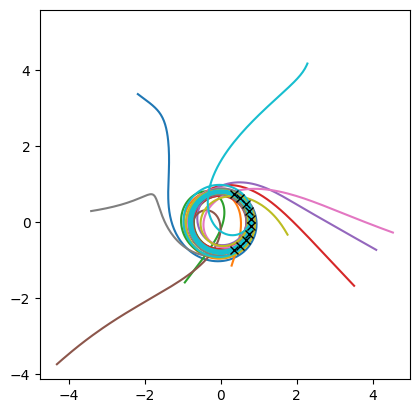

In [8]:
def vec(t,tray):
    evol = vecpf(t,tray)+vecco(t,tray)
    return evol

trayectoria = solve_ivp(vec,t_sim,rob0,method='RK45',rtol=1e-8,atol=1e-10)

for i in range(nrob):
    plt.plot(trayectoria.y[i*3],trayectoria.y[i*3+1])

for i in range(nrob):
    plt.plot(trayectoria.y[i*3,-1],trayectoria.y[i*3+1,-1],marker='x',color='black')

plt.xlim(posmin,posmax)
plt.ylim(posmin,posmax)
plt.axis('square')


plt.show

In [9]:
# #Definir w_f es únicamente para dibujar la curva f(t)
# w_f = []

# def vec(t,tray):
#     evol = vecpf(t,tray)+vecco(t,tray)
#     return evol

# for i in range(nrob):  
#     Trayectoria = 0
#     Trayectoria = solve_ivp(vec,t_sim,rob0[:,i],method='RK45',rtol=1e-8,atol=1e-10)

#     #Esto es para obtener el parametro w hasta el que dibujar la curva a la que tienden los robots
#     w_f.append((Trayectoria.y[2])[-1])

#     #Dibujamos posiciones iniciales con x, y las trayectorias
#     plt.plot(rob0[0,i],rob0[1,i],marker='x',color='k')
#     plt.plot(Trayectoria.y[0],Trayectoria.y[1],alpha = 0.3)

# #Dibujamos la curva hasta la posición del robot que más a trazado la curva
# t_dibujo = np.linspace(0,max(w_f),500)
# dibujo = f(t_dibujo)

# plt.xlim(posmin,posmax)
# plt.ylim(posmin,posmax)
# plt.axis('square')
# plt.plot(dibujo[0],dibujo[1],'r--')

# plt.show()